In [4]:
import pandas as pd
from itables import show
from scipy import stats



data = pd.read_csv("student-mat.csv", sep=";")
selected_cols = data[["address", "paid"]]


sad = pd.crosstab(selected_cols["address"], selected_cols["paid"])

show(sad)

chisq_output = stats.chi2_contingency(sad)

print(f"The p-value is {chisq_output.pvalue:.3f}.")
## The p-value is 0.228.
print(f"The test-statistic value is {chisq_output.statistic:.3f}.")

Loading ITables v2.6.2 from the internet... (need help?)


The p-value is 0.353.
The test-statistic value is 0.861.


<Axes: xlabel='address'>

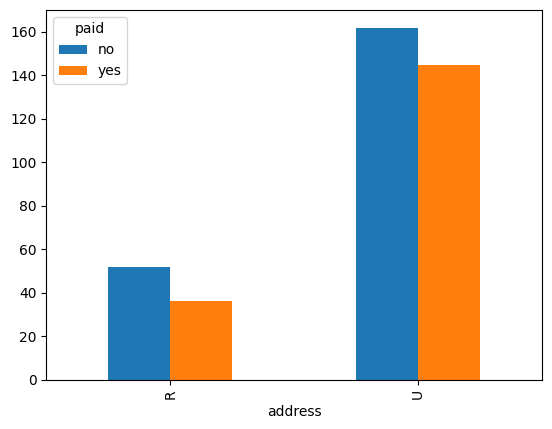

In [5]:
sad.plot(kind="bar")

Loading ITables v2.6.2 from the internet... (need help?)


<Axes: xlabel='address'>

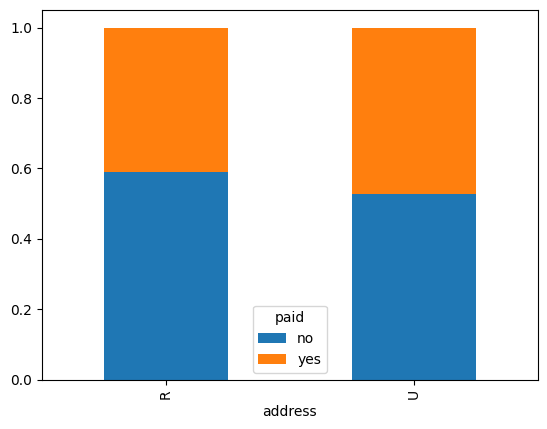

In [7]:
gae = pd.crosstab(selected_cols["address"], selected_cols["paid"], normalize="index")

show(gae)

gae.plot(kind="bar", stacked=True)

In [8]:
relative_risk = gae["yes"]["R"] / gae["yes"]["U"]
print(relative_risk)


0.8661442006269593


In [22]:
bins = [0, 10, 12, 15, 18, 20]
grades = ["F", "D", "C", "B", "A"]
res = pd.cut(data["G3"], bins=bins, labels=grades, ordered=True)
data["letter_grade"] = res
print(data["letter_grade"].value_counts())
show(res)

letter_grade
F    148
C     91
D     78
B     34
A      6
Name: count, dtype: int64


Loading ITables v2.6.2 from the internet... (need help?)


In [35]:
cols = ["famrel","freetime","goout","Dalc","Walc","health"]
data["cat"] = data["letter_grade"].astype("category").cat.codes
for x in cols:
    print(f"{x}: {stats.kendalltau(data.letter_grade, data[x])}")


famrel: SignificanceResult(statistic=np.float64(nan), pvalue=np.float64(nan))
freetime: SignificanceResult(statistic=np.float64(nan), pvalue=np.float64(nan))
goout: SignificanceResult(statistic=np.float64(nan), pvalue=np.float64(nan))
Dalc: SignificanceResult(statistic=np.float64(nan), pvalue=np.float64(nan))
Walc: SignificanceResult(statistic=np.float64(nan), pvalue=np.float64(nan))
health: SignificanceResult(statistic=np.float64(nan), pvalue=np.float64(nan))
